In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
dia =datasets.load_diabetes()
dia.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [13]:
dia.data.shape

(442, 10)

In [21]:
dia.target.shape

(442,)

In [15]:
dia.data[:5]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087]])

In [25]:
df = pd.DataFrame(dia.data, columns=dia.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [31]:
dia_X = df['bmi'].values.reshape(-1,1)
dia_X.shape

(442, 1)

In [39]:
dia_X_train = dia_X[:-20]
dia_X_test = dia_X[-20:]
dia_X_train.shape,dia_X_test.shape

((422, 1), (20, 1))

In [41]:
dia_y_train = dia.target[:-20]
dia_y_test = dia.target[-20:]

dia_y_train.shape, dia_y_test.shape

((422,), (20,))

In [45]:
regr = linear_model.LinearRegression()

regr.fit(dia_X_train, dia_y_train)#훈련 data 넣기, Linear학습

LinearRegression()

In [49]:
regr.coef_ #기울기

array([938.23786125])

In [51]:
regr.intercept_

152.91886182616113

In [53]:
y_pred = regr.predict(dia_X_test)
y_pred

array([225.9732401 , 115.74763374, 163.27610621, 114.73638965,
       120.80385422, 158.21988574, 236.08568105, 121.81509832,
        99.56772822, 123.83758651, 204.73711411,  96.53399594,
       154.17490936, 130.91629517,  83.3878227 , 171.36605897,
       137.99500384, 137.99500384, 189.56845268,  84.3990668 ])

In [55]:
dia_y_test

array([233.,  91., 111., 152., 120.,  67., 310.,  94., 183.,  66., 173.,
        72.,  49.,  64.,  48., 178., 104., 132., 220.,  57.])

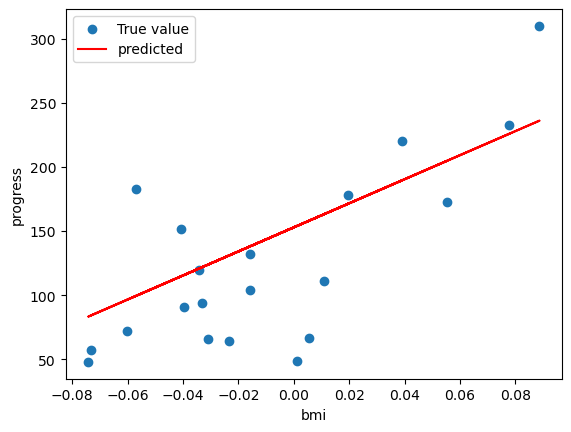

In [69]:
plt.scatter(dia_X_test, dia_y_test,label='True value')
plt.plot(dia_X_test, y_pred, color='r', label='predicted')
plt.xlabel("bmi")
plt.ylabel("progress")
plt.legend()

In [73]:
r2_score(dia_y_test, y_pred)

0.47257544798227147

In [75]:
mean_squared_error(dia_y_test, y_pred)

2548.0723987259694

In [77]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [97]:
dia_X = df.values #= df[['bmi','bp']].values
dia_X.shape

(442, 10)

In [99]:
dia_X_train = dia_X[:-20]
dia_X_test = dia_X[-20:]

dia_X_train.shape, dia_X_test.shape

((422, 10), (20, 10))

In [101]:
dia_y_train = dia.target[:-20]
dia_y_test = dia.target[-20:]

dia_y_train.shape, dia_y_test.shape

((422,), (20,))

In [103]:
regr=linear_model.LinearRegression()
regr.fit(dia_X_train, dia_y_train)

LinearRegression()

In [105]:
y_pred=regr.predict(dia_X_test) #예측
y_pred
r2_score(dia_y_test, y_pred)

0.585085427447195